---
title: Priors and schedules
---

This page covers the prior distributions, step size schedules, and regularization schedules available for use with SVGD inference.

In [1]:
from phasic import (
    Graph, with_ipv,
    # Priors
    GaussPrior, HalfCauchyPrior, DataPrior,
    # Step size schedules
    ConstantStepSize, ExpStepSize, AdaptiveStepSize, WarmupExpStepSize,
    # Regularization schedules
    ConstantRegularization, ExpRegularization, ExponentialCDFRegularization,
    # Optimizers (for examples)
    Adam,
)
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)
try:
    from vscodenb import set_vscode_theme
    set_vscode_theme()
except ImportError:
    pass
sns.set_palette('tab10')

## Priors

### GaussPrior

A Gaussian (normal) prior centred on a point estimate with a given spread. It can be specified either by the mean and standard deviation or by a credible interval. E.g., "I believe the parameter is between 2 and 8 with 95% probability" translates directly to `GaussPrior(ci=(2, 8))`. The two specifications are equivalent: a 95% credible interval `[low, high]` maps to `mean = (low + high) / 2` and `std = (high - low) / (2 * z_0.975)`.

<Figure size 640x480 with 0 Axes>

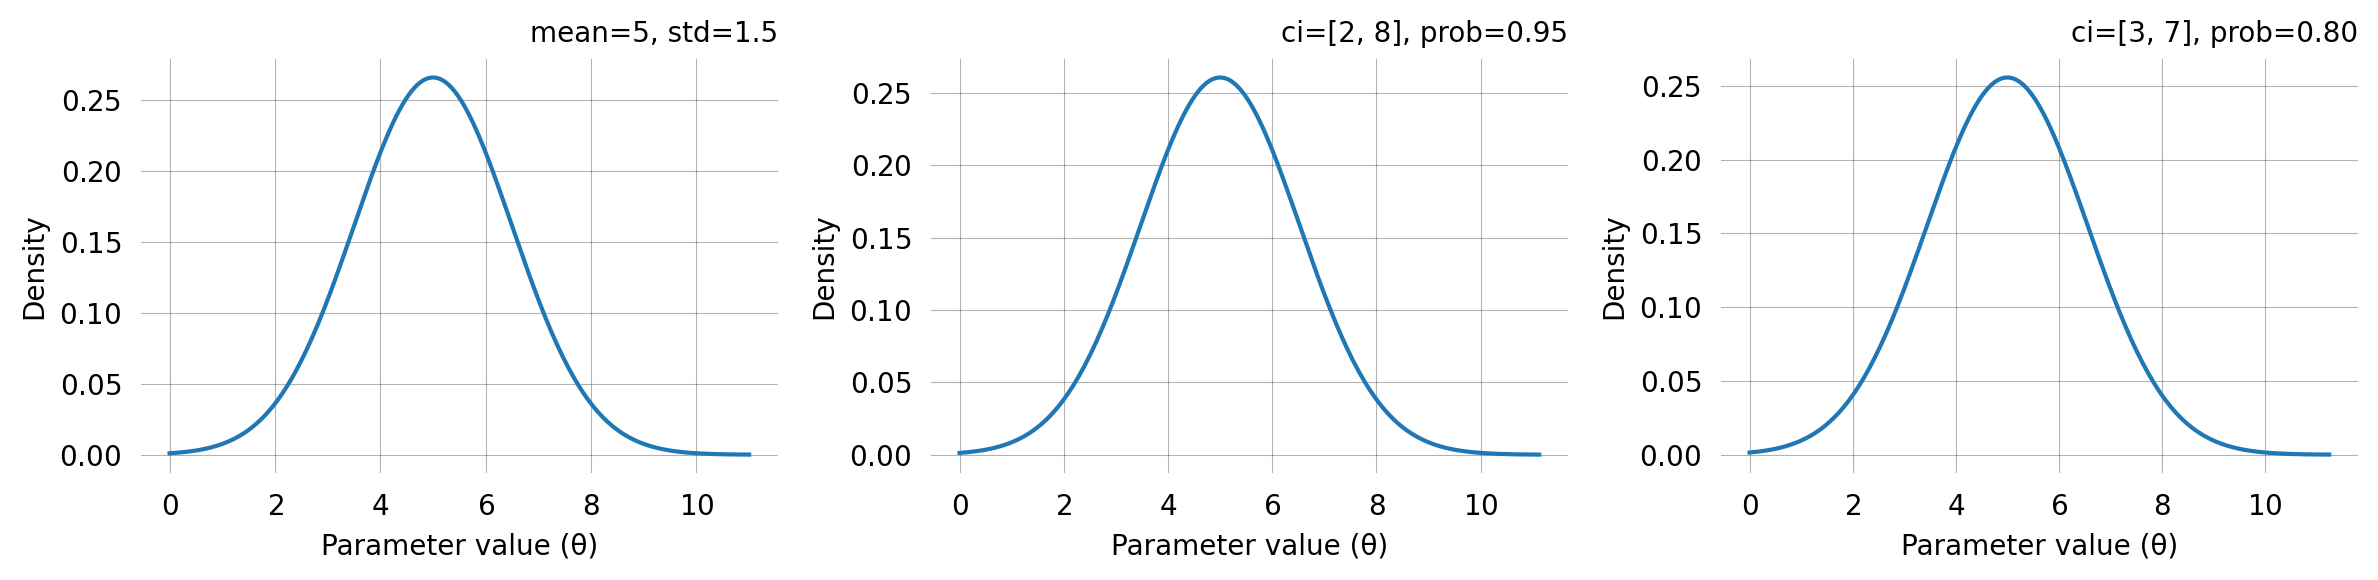

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# 1. Mean + std
p1 = GaussPrior(mean=5.0, std=1.5)
p1.plot(ax=axes[0], return_ax=True)
axes[0].set_title(f'mean=5, std=1.5')

# 2. 95% credible interval
p2 = GaussPrior(ci=(2.0, 8.0))
p2.plot(ax=axes[1], return_ax=True)
axes[1].set_title(f'ci=[2, 8], prob=0.95')

# 3. 80% credible interval (tighter)
p3 = GaussPrior(ci=(3.0, 7.0), prob=0.80)
p3.plot(ax=axes[2], return_ax=True)
axes[2].set_title(f'ci=[3, 7], prob=0.80')

plt.tight_layout()

### HalfCauchyPrior

A half-Cauchy prior with support on $(0, \infty)$. Its heavy tails make it a popular weakly informative prior for scale and rate parameters. Concentrates mass near zero but allows for large values.

$$
f(\theta) = \frac{2}{\pi \, \gamma \left(1 + (\theta/\gamma)^2\right)}, \quad \theta > 0
$$

It can be specified via the scale parameter $\gamma$ directly, or via a credible-interval upper bound. The CI specification says: "I believe there is a `prob` probability that the parameter is below `ci`." A lower `prob` for the same `ci` implies a larger scale (heavier tail).

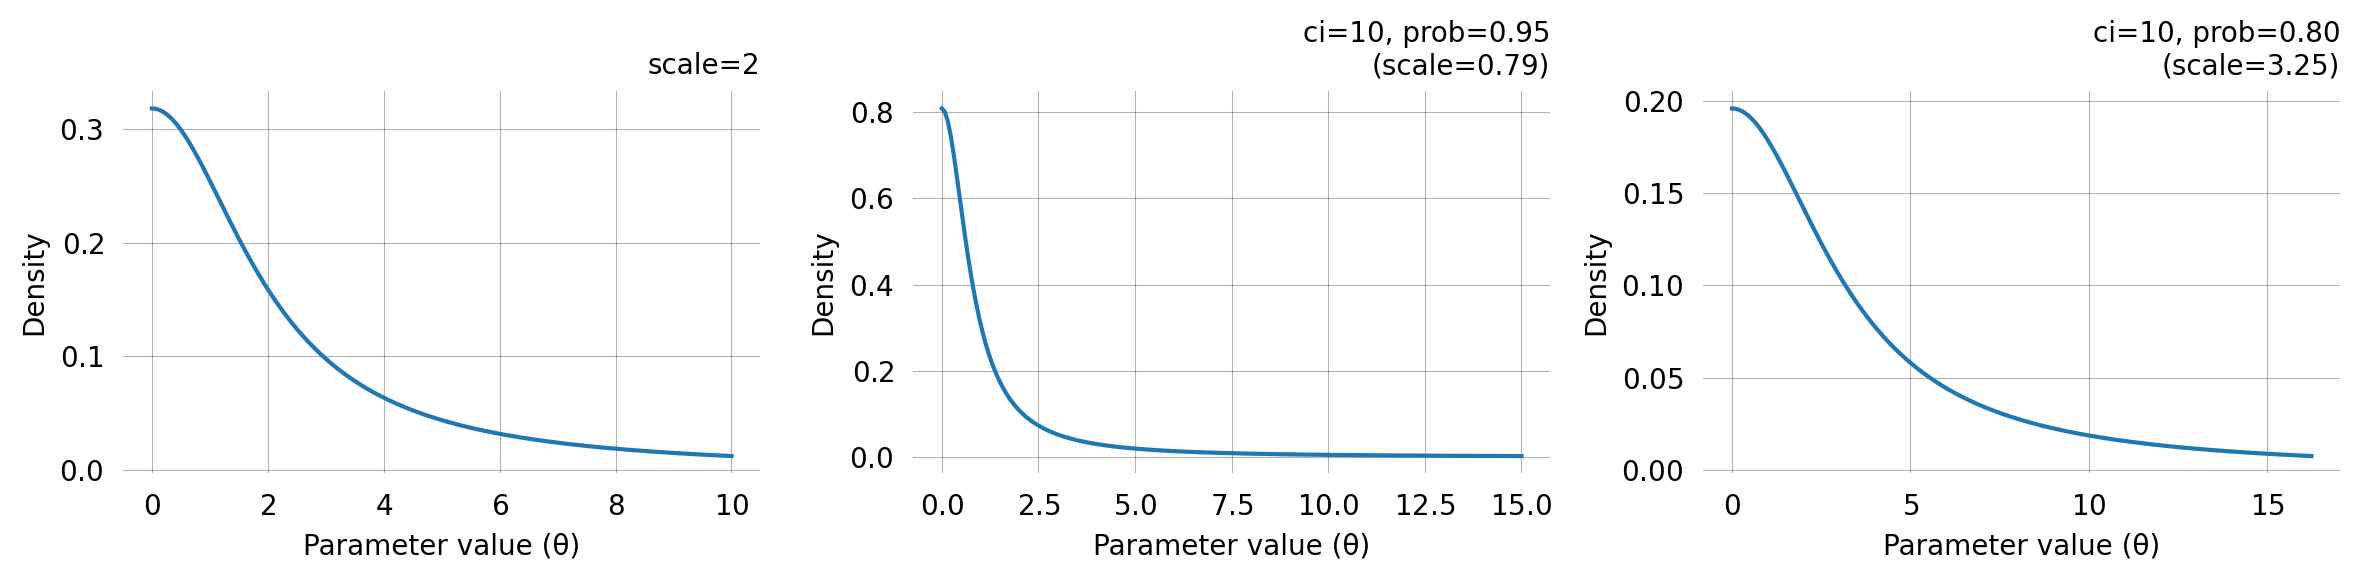

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# 1. Scale parameter
h1 = HalfCauchyPrior(scale=2.0)
h1.plot(ax=axes[0], return_ax=True)
axes[0].set_title('scale=2')

# 2. 95% CI upper bound
h2 = HalfCauchyPrior(ci=10.0)
h2.plot(ax=axes[1], return_ax=True)
axes[1].set_title(f'ci=10, prob=0.95\n(scale={h2.scale:.2f})')

# 3. 80% CI upper bound
h3 = HalfCauchyPrior(ci=10.0, prob=0.80)
h3.plot(ax=axes[2], return_ax=True)
axes[2].set_title(f'ci=10, prob=0.80\n(scale={h3.scale:.2f})')

plt.tight_layout()

### DataPrior

`DataPrior` constructs a data-informed prior automatically. Instead of specifying mean and spread by hand, it estimates them from the observed data using either method of moments (standard phase-type graphs) or probability matching (joint probability graphs). The graph type is detected automatically. The result is a list of per-parameter `GaussPrior` objects (with `None` at fixed-parameter positions) that integrates directly with `graph.svgd()`.

In [4]:
# Build a simple coalescent model
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)

true_theta = [7.0]
graph.update_weights(true_theta)
data = graph.sample(1000)

In [5]:
dp = DataPrior(graph, data, sd=2.0)
print(dp)
print(f"Method:    {dp.method}")
print(f"Theta:     {dp.theta}")
print(f"Std:       {dp.std}")
print(f"Converged: {dp.success}")

DataPrior(method=method_of_moments, converged, theta=[7.0081])
Method:    method_of_moments
Theta:     [7.00810687]
Std:       [0.14919403]
Converged: True


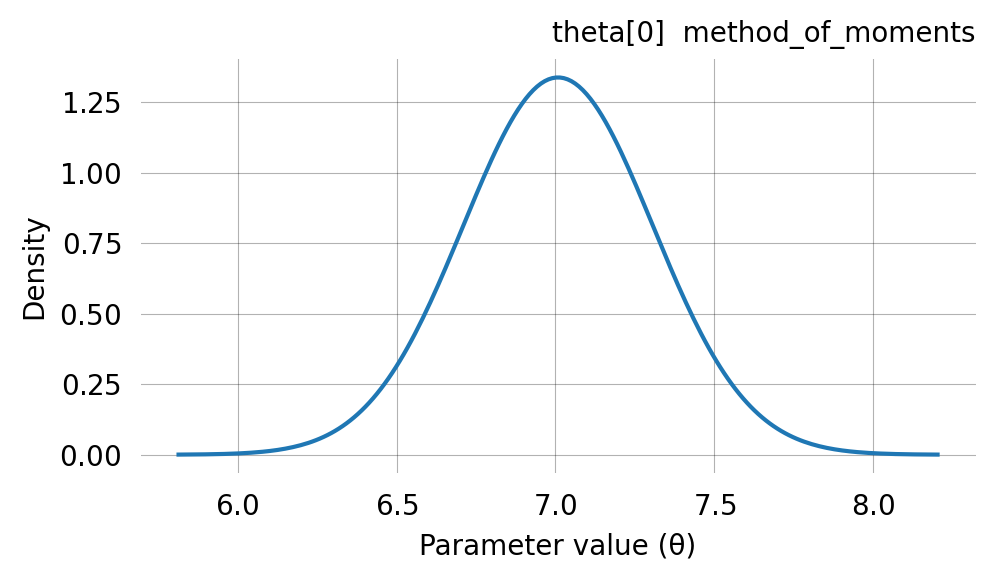

In [6]:
dp.plot()

`DataPrior` is iterable — you can inspect individual per-parameter priors and pass it directly to `graph.svgd()` as the `prior` argument:

In [7]:
# Inspect per-parameter priors
print(f"Number of parameters: {len(dp)}")
for i, p in enumerate(dp):
    if p is not None:
        print(f"  theta[{i}]: GaussPrior(mean={p.mu:.3f}, std={p.sigma:.3f})")
    else:
        print(f"  theta[{i}]: None (fixed)")

Number of parameters: 1
  theta[0]: GaussPrior(mean=7.008, std=0.298)


In [8]:
# Use directly with SVGD
svgd = graph.svgd(data, prior=dp, optimizer=Adam(0.25))
svgd.summary()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         7.0206     6.9988     0.1432     6.8744       7.3882      

Particles: 24, Iterations: 100


See the API documentation on `DataPrior` for all parameters.

### Per-parameter priors

When a model has multiple parameters, you can assign a different prior to each one by passing a list of prior objects to `graph.svgd()`. Use `None` at positions corresponding to fixed parameters:

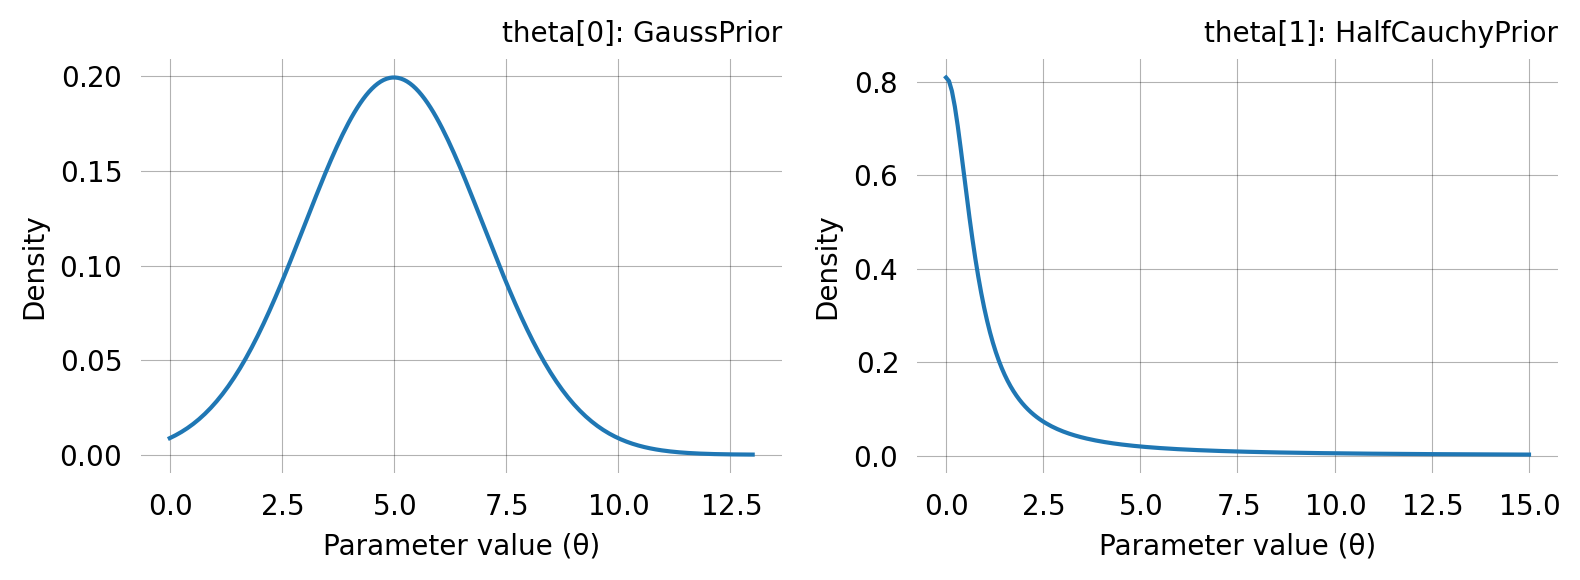

In [9]:
per_param_priors = [
    GaussPrior(mean=5.0, std=2.0),   # theta[0]
    HalfCauchyPrior(ci=10.0),        # theta[1]
]

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
per_param_priors[0].plot(ax=axes[0], return_ax=True)
axes[0].set_title('theta[0]: GaussPrior')
per_param_priors[1].plot(ax=axes[1], return_ax=True)
axes[1].set_title('theta[1]: HalfCauchyPrior')
plt.tight_layout()

## Step size schedules

The step size (learning rate) controls how far particles move at each SVGD iteration. A step size that is too large causes oscillation; too small causes slow convergence. Schedules let you vary the step size over the course of optimization. Pass a schedule to `graph.svgd()` via the `learning_rate` parameter, or to an optimizer like `Adam(learning_rate=schedule)`.

### ConstantStepSize

The simplest schedule: the same step size at every iteration. This is also the implicit default when you pass a plain number as the `learning_rate`.

Step at iteration 0:   0.01
Step at iteration 500: 0.01


<Axes: title={'right': 'ConstantStepSize'}, xlabel='Iteration', ylabel='Step Size'>

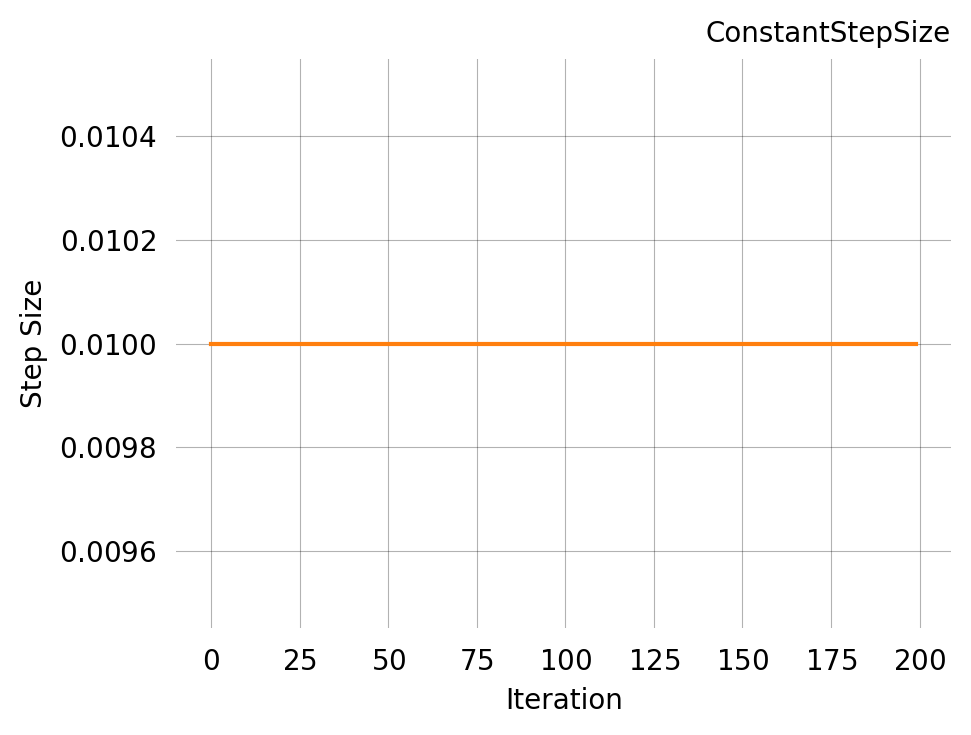

In [10]:
const = ConstantStepSize(0.01)
print(f"Step at iteration 0:   {const(0)}")
print(f"Step at iteration 500: {const(500)}")

const.plot(200)

Se the API documentation for `ConstantStepSize` for all parameters.

### ExpStepSize

Exponential decay from `first_step` to `last_step` with time constant `tau`:

$$
\eta(t) = \eta_0 \, e^{-t/\tau} + \eta_\infty \left(1 - e^{-t/\tau}\right)
$$

At $t = \tau$, roughly 63% of the decay has occurred. This is the most commonly used schedule — start with a large step to explore, then settle down for fine-tuning.

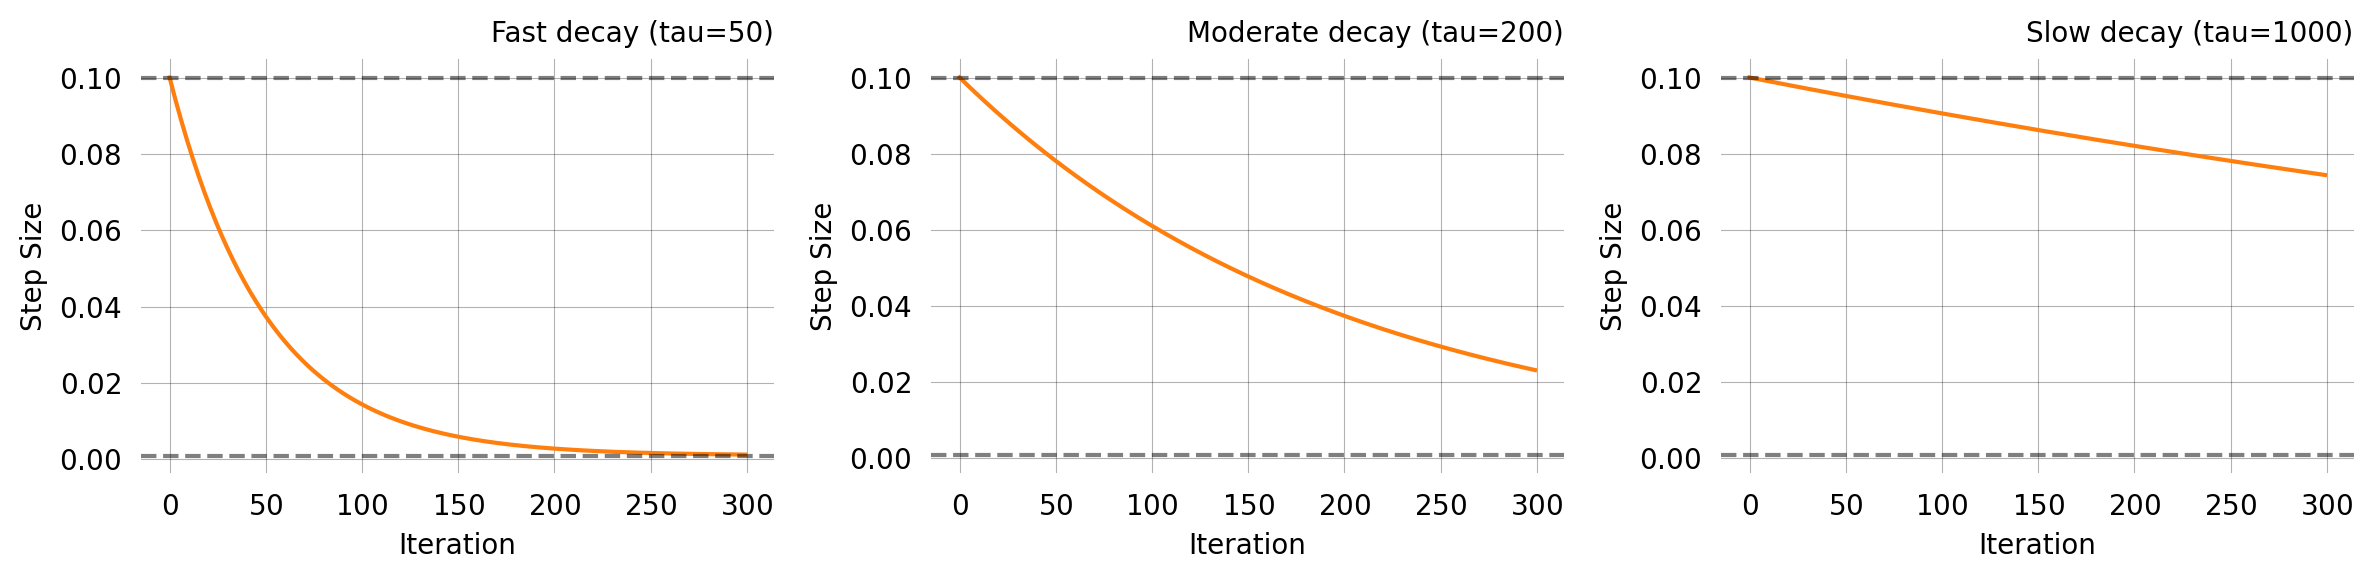

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Fast decay
s1 = ExpStepSize(first_step=0.1, last_step=0.001, tau=50.0)
s1.plot(300, ax=axes[0], return_ax=True)
axes[0].set_title('Fast decay (tau=50)')

# Moderate decay
s2 = ExpStepSize(first_step=0.1, last_step=0.001, tau=200.0)
s2.plot(300, ax=axes[1], return_ax=True)
axes[1].set_title('Moderate decay (tau=200)')

# Slow decay
s3 = ExpStepSize(first_step=0.1, last_step=0.001, tau=1000.0)
s3.plot(300, ax=axes[2], return_ax=True)
axes[2].set_title('Slow decay (tau=1000)')

plt.tight_layout()

Se the API documentation for `ExpStepSize` for all parameters.

### WarmupExpStepSize

A linear ramp-up phase followed by exponential decay. This is useful with Adam and other adaptive optimizers where moment estimates are poorly calibrated in the first few iterations — a warmup prevents large early updates.

$$
\eta(t) = \begin{cases}
\eta_{\text{peak}} \cdot \frac{t+1}{T_{\text{warmup}}} & t < T_{\text{warmup}} \\
\eta_{\text{peak}} \, e^{-(t - T_{\text{warmup}})/\tau} + \eta_\infty \left(1 - e^{-(t - T_{\text{warmup}})/\tau}\right) & t \geq T_{\text{warmup}}
\end{cases}
$$

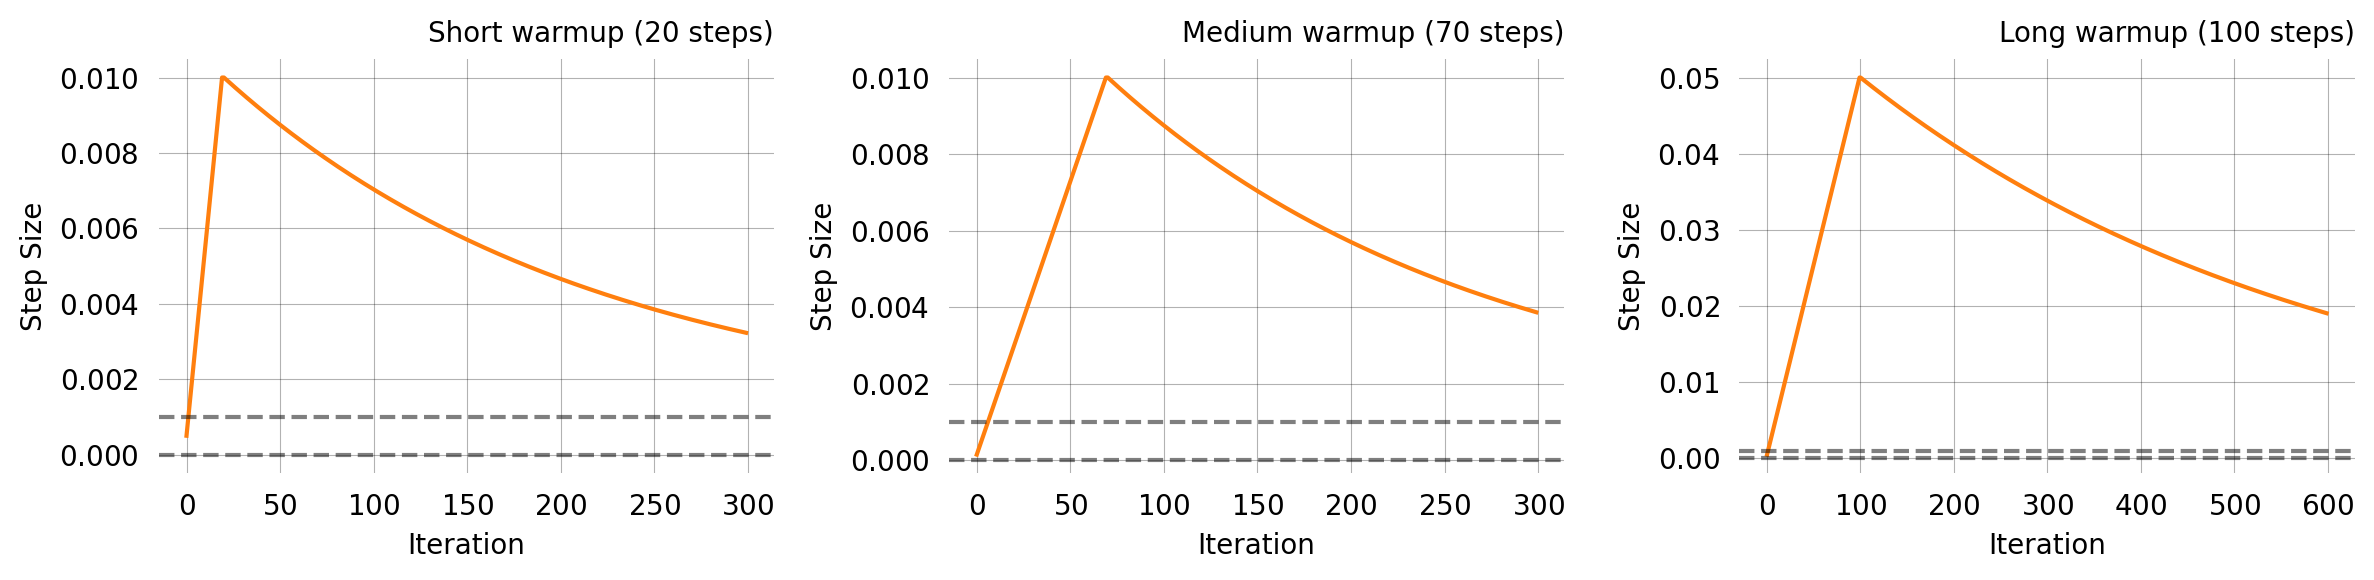

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Short warmup
w1 = WarmupExpStepSize(peak_lr=0.01, warmup_steps=20, last_lr=0.001, tau=200.0)
w1.plot(300, ax=axes[0], return_ax=True)
axes[0].set_title('Short warmup (20 steps)')

# Medium warmup
w2 = WarmupExpStepSize(peak_lr=0.01, warmup_steps=70, last_lr=0.001, tau=200.0)
w2.plot(300, ax=axes[1], return_ax=True)
axes[1].set_title('Medium warmup (70 steps)')

# Long warmup, high peak
w3 = WarmupExpStepSize(peak_lr=0.05, warmup_steps=100, last_lr=0.001, tau=500.0)
w3.plot(600, ax=axes[2], return_ax=True)
axes[2].set_title('Long warmup (100 steps)')

plt.tight_layout()

Se the API documentation for `WarmupExpStepSize` for all parameters.

### AdaptiveStepSize

Adjusts the step size dynamically based on particle spread. When particles are too concentrated the step size increases; when too dispersed it decreases. This is a simple heuristic that does not require tuning a decay schedule, but its behaviour depends on the optimisation trajectory.

In [13]:
adaptive = AdaptiveStepSize(base_step=0.01, kl_target=0.1, adjust_rate=0.1)
print(f"Base step: {adaptive.base_step}")
print(f"Without particles: {adaptive(0):.4f}")

# Simulate concentrated particles
concentrated = jnp.array([[1.0], [1.01], [0.99]])
print(f"Concentrated particles: {adaptive(1, concentrated):.4f} (increases)")

# Simulate spread particles
spread = jnp.array([[1.0], [10.0], [100.0]])
print(f"Spread particles: {adaptive(2, spread):.4f} (decreases)")

Base step: 0.01
Without particles: 0.0100
Concentrated particles: 0.0110 (increases)
Spread particles: 0.0099 (decreases)


Se the API documentation for `AdaptiveStepSize` for all parameters.

### Comparison

All four schedules on the same axes for a 300-iteration run:

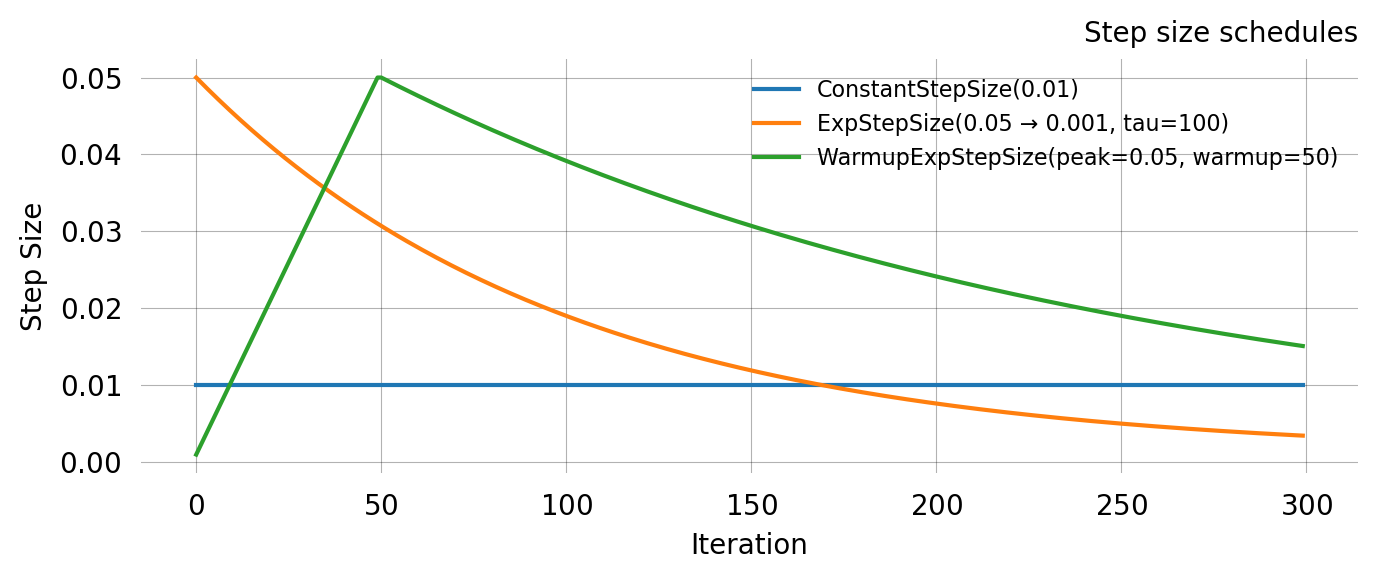

In [14]:
nr_iter = 300
iters = np.arange(nr_iter)

schedules = {
    'ConstantStepSize(0.01)': ConstantStepSize(0.01),
    'ExpStepSize(0.05 → 0.001, tau=100)': ExpStepSize(0.05, 0.001, 100.0),
    'WarmupExpStepSize(peak=0.05, warmup=50)': WarmupExpStepSize(0.05, 50, 0.001, 200.0),
}

fig, ax = plt.subplots(figsize=(7, 3))
for label, sched in schedules.items():
    vals = [float(sched(i)) for i in iters]
    ax.plot(iters, vals, label=label)

ax.set_xlabel('Iteration')
ax.set_ylabel('Step Size')
ax.set_title('Step size schedules')
ax.legend(fontsize=8)
plt.tight_layout()

## Regularization schedules

Moment regularization adds a penalty term to the SVGD objective that encourages the model moments at the current parameter values to match the empirical moments. This is controlled by the `regularization` parameter in `graph.svgd()` and requires specifying `nr_moments`. Strong regularization early in optimization helps guide particles into a reasonable region; reducing it later lets the likelihood dominate for fine-tuning.

### ConstantRegularization

A fixed regularization strength throughout optimisation.

Strength at iteration 0:   1.0
Strength at iteration 500: 1.0


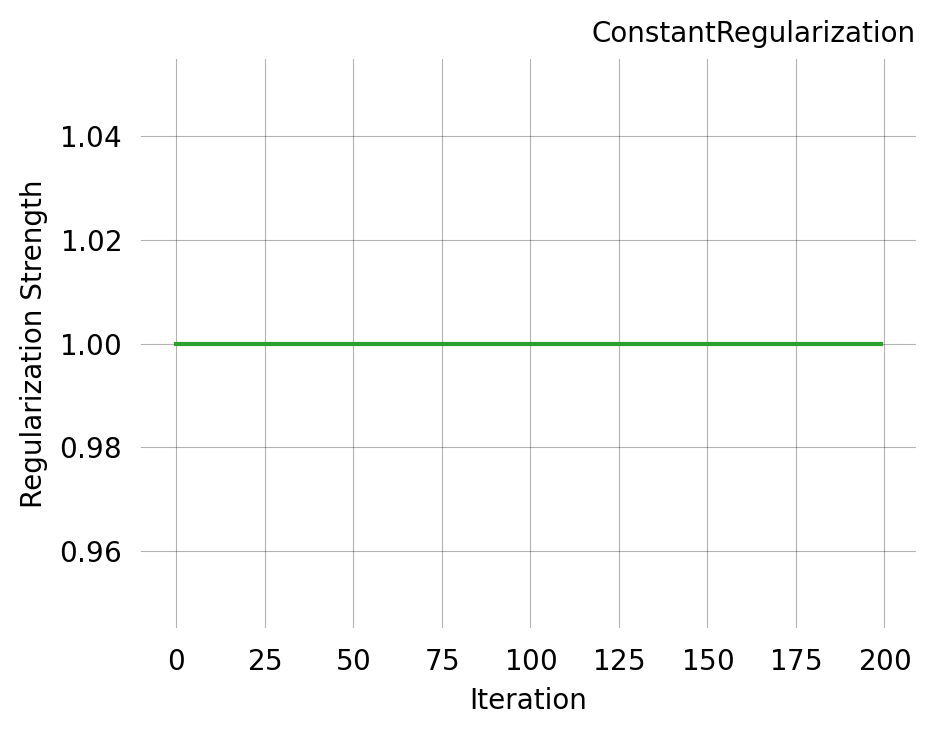

In [15]:
const_reg = ConstantRegularization(1.0)
print(f"Strength at iteration 0:   {const_reg(0)}")
print(f"Strength at iteration 500: {const_reg(500)}")

const_reg.plot(200)

Se the API documentation for `ConstantRegularization` for all parameters.

### ExpRegularization

Exponential decay, identical in form to `ExpStepSize`:

$$
\lambda(t) = \lambda_0 \, e^{-t/\tau} + \lambda_\infty \left(1 - e^{-t/\tau}\right)
$$

Start with strong regularization to guide particles, then reduce to let the likelihood dominate.

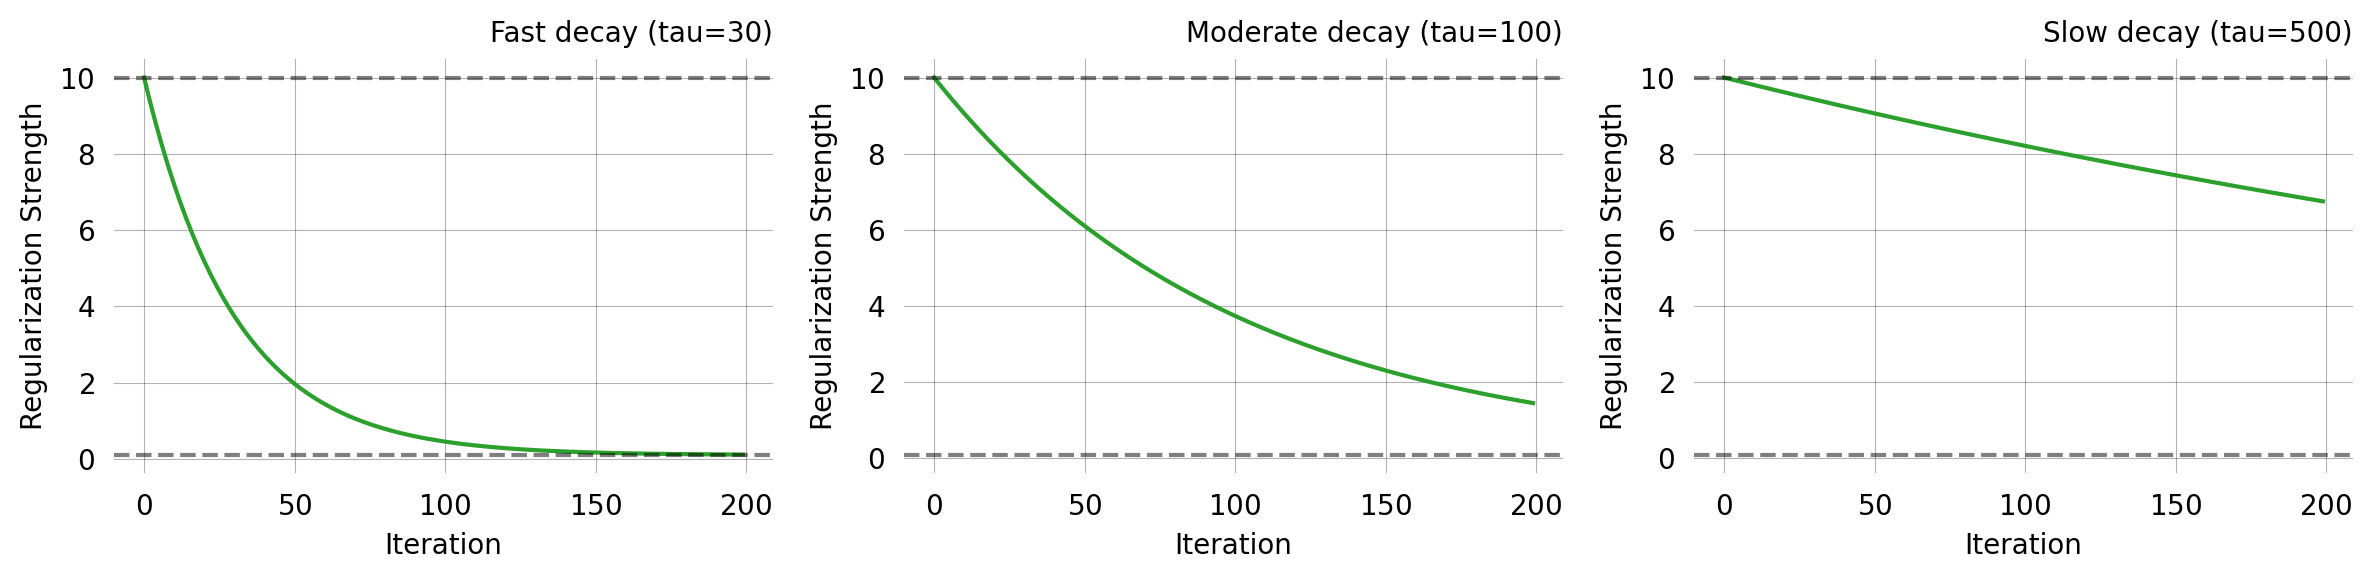

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

r1 = ExpRegularization(first_reg=10.0, last_reg=0.1, tau=30.0)
r1.plot(200, ax=axes[0], return_ax=True)
axes[0].set_title('Fast decay (tau=30)')

r2 = ExpRegularization(first_reg=10.0, last_reg=0.1, tau=100.0)
r2.plot(200, ax=axes[1], return_ax=True)
axes[1].set_title('Moderate decay (tau=100)')

r3 = ExpRegularization(first_reg=10.0, last_reg=0.1, tau=500.0)
r3.plot(200, ax=axes[2], return_ax=True)
axes[2].set_title('Slow decay (tau=500)')

plt.tight_layout()

Se the API documentation for `ExpRegularization` for all parameters.

### ExponentialCDFRegularization

Uses the exponential CDF for a smooth S-curve transition:

$$
\lambda(t) = \lambda_0 + (\lambda_\infty - \lambda_0) \left(1 - e^{-t/\tau}\right)
$$

This is mathematically equivalent to `ExpRegularization` for decreasing schedules, but the parameterisation makes it equally natural for *increasing* schedules — useful for progressive regularization where you start with pure likelihood and gradually add moment matching.

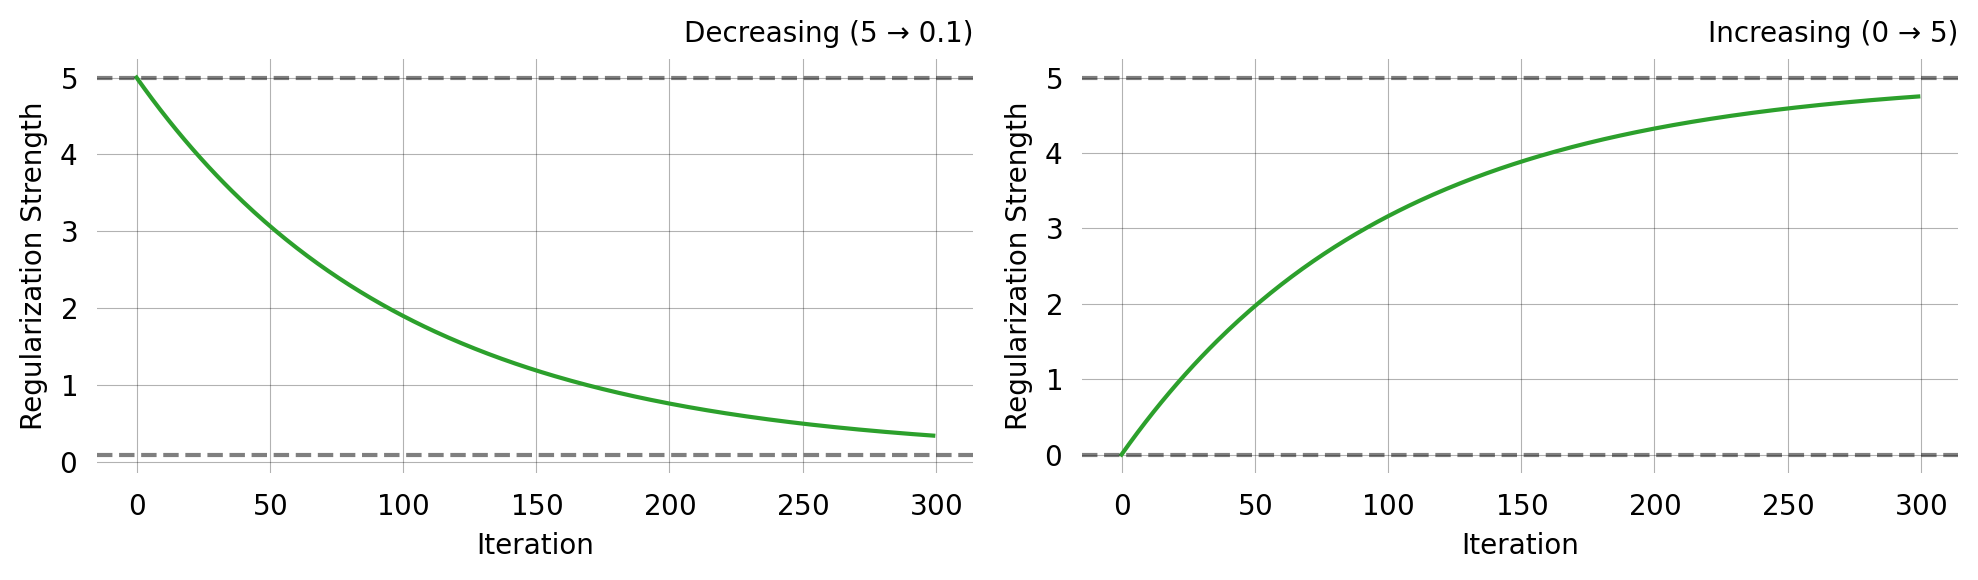

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Decreasing (same as ExpRegularization)
c1 = ExponentialCDFRegularization(first_reg=5.0, last_reg=0.1, tau=100.0)
c1.plot(300, ax=axes[0], return_ax=True)
axes[0].set_title('Decreasing (5 → 0.1)')

# Increasing — start with likelihood only, add regularization later
c2 = ExponentialCDFRegularization(first_reg=0.0, last_reg=5.0, tau=100.0)
c2.plot(300, ax=axes[1], return_ax=True)
axes[1].set_title('Increasing (0 → 5)')

plt.tight_layout()

Se the API documentation for `ExponentialCDFRegularization` for all parameters.

### Comparison

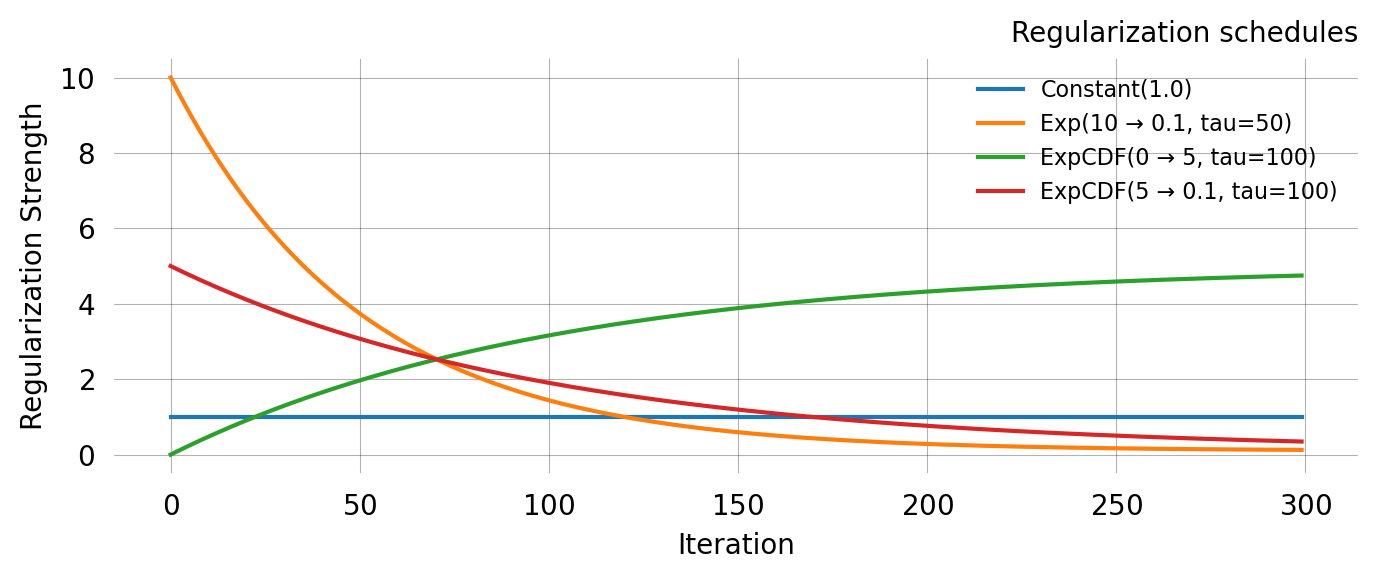

In [18]:
nr_iter = 300
iters = np.arange(nr_iter)

reg_schedules = {
    'Constant(1.0)': ConstantRegularization(1.0),
    'Exp(10 → 0.1, tau=50)': ExpRegularization(10.0, 0.1, 50.0),
    'ExpCDF(0 → 5, tau=100)': ExponentialCDFRegularization(0.0, 5.0, 100.0),
    'ExpCDF(5 → 0.1, tau=100)': ExponentialCDFRegularization(5.0, 0.1, 100.0),
}

fig, ax = plt.subplots(figsize=(7, 3))
for label, sched in reg_schedules.items():
    vals = [float(sched(i)) for i in iters]
    ax.plot(iters, vals, label=label)

ax.set_xlabel('Iteration')
ax.set_ylabel('Regularization Strength')
ax.set_title('Regularization schedules')
ax.legend(fontsize=8)
plt.tight_layout()

## Putting it together

A typical SVGD call combining priors and schedules:

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         7.0201     7.0194     0.0230     6.9676       7.0501      

Particles: 24, Iterations: 200


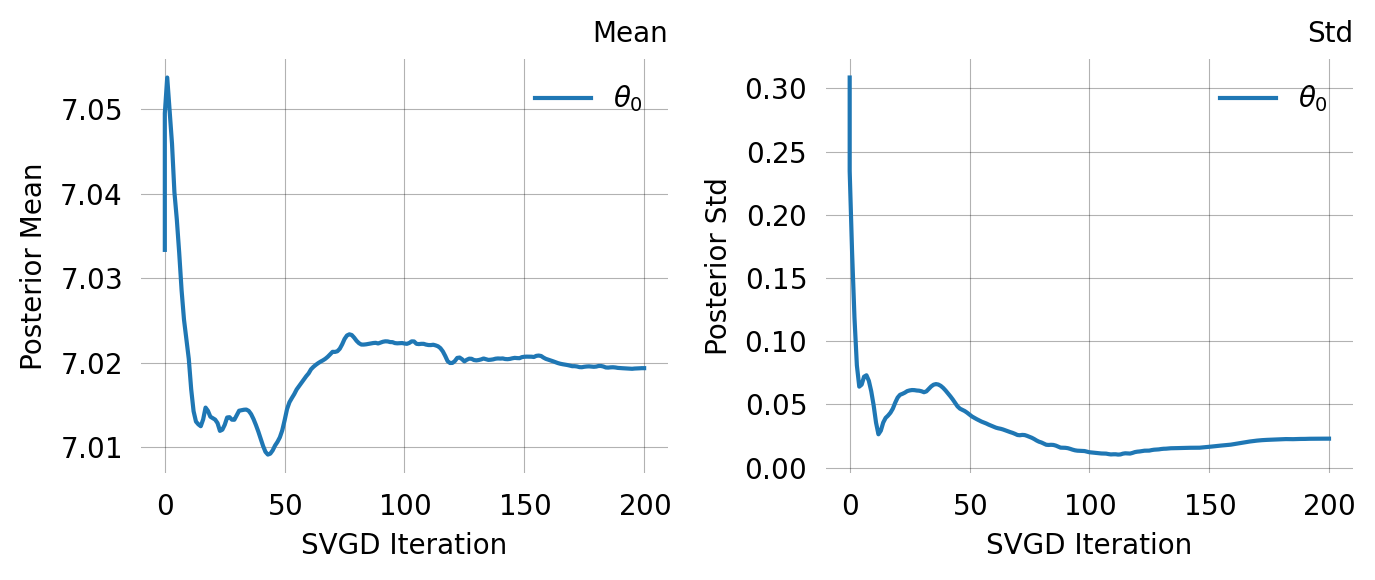

In [19]:
svgd = graph.svgd(
    data,
    prior=DataPrior(graph, data, sd=2.0),
    optimizer=Adam(
        learning_rate=ExpStepSize(first_step=0.1, last_step=0.01, tau=30.0),
    ),
    # regularization=ExpRegularization(first_reg=5.0, last_reg=0.1, tau=20.0),
    # nr_moments=2,
    n_iterations=200,
)
svgd.summary()
svgd.plot_convergence() ;